# Exploratory Data Analysis
### Inventory & Vendor Performance Project | 2026

This notebook explores the raw tables loaded into `inventory.db` to:
- Understand the structure and quality of each table
- Identify data issues, anomalies and outliers
- Document decisions made before building the vendor summary
- Provide the analytical foundation for the Power BI dashboard

In [3]:
# ─────────────────────────────────────────────
# IMPORTS & DATABASE CONNECTION
# ─────────────────────────────────────────────
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set default plot style for all charts in this notebook
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Connect to the SQLite database
conn = sqlite3.connect('../inventory.db')
print("Connected to inventory.db successfully")

Connected to inventory.db successfully


## 1. Database Overview

First, let's confirm all 6 tables loaded correctly and check their row counts.

In [4]:
# ─────────────────────────────────────────────
# VERIFY ALL TABLES ARE PRESENT IN THE DATABASE
# ─────────────────────────────────────────────

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table'", conn
)

print("Tables in database:")
for table in tables['name']:
    count = pd.read_sql_query(
        f"SELECT COUNT(*) as cnt FROM {table}", conn
    )
    print(f"  {table:<25} {count['cnt'].iloc[0]:>12,} rows")

Tables in database:
  begin_inventory                206,529 rows
  end_inventory                  224,489 rows
  purchases                    2,372,474 rows
  purchase_prices                 12,261 rows
  sales                       12,825,363 rows
  vendor_invoice                   5,543 rows
  vendor_sales_summary            10,514 rows


## 2. Table Profiling

We profile each raw table to understand:
- Column data types
- Null values and their extent
- Basic distributions and ranges
- Any immediate data quality concerns

### 2.1 Vendor Invoice
This table contains invoice-level purchase records from vendors.
It is the source of freight cost data used in the vendor summary.

In [5]:
# ─────────────────────────────────────────────
# VENDOR INVOICE — PROFILE
# ─────────────────────────────────────────────

vendor_invoice = pd.read_sql_query("SELECT * FROM vendor_invoice", conn)

print(f"Shape: {vendor_invoice.shape}")
print(f"\nData Types:\n{vendor_invoice.dtypes}")
print(f"\nNull Counts:\n{vendor_invoice.isnull().sum()}")
print(f"\nSample Records:")
vendor_invoice.head(3)

Shape: (5543, 9)

Data Types:
VendorNumber      int64
VendorName       object
InvoiceDate      object
PONumber          int64
PODate           object
PayDate          object
Quantity          int64
Dollars         float64
Freight         float64
dtype: object

Null Counts:
VendorNumber    0
VendorName      0
InvoiceDate     0
PONumber        0
PODate          0
PayDate         0
Quantity        0
Dollars         0
Freight         0
dtype: int64

Sample Records:


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight
0,105,ALTAMAR BRANDS LLC,2024-01-04 00:00:00,8124,2023-12-21 00:00:00,2024-02-16 00:00:00,6,214.26,3.47
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07 00:00:00,8137,2023-12-22 00:00:00,2024-02-21 00:00:00,15,140.55,8.57
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09 00:00:00,8169,2023-12-24 00:00:00,2024-02-16 00:00:00,5,106.60,4.61


In [6]:
# ─────────────────────────────────────────────
# VENDOR INVOICE — KEY OBSERVATIONS
# ─────────────────────────────────────────────

print("=== Vendor Invoice — Key Stats ===\n")

# Date range of invoices
print(f"Invoice Date Range : {vendor_invoice['InvoiceDate'].min()} "
      f"to {vendor_invoice['InvoiceDate'].max()}")

# Unique vendors
print(f"Unique Vendors     : {vendor_invoice['VendorNumber'].nunique()}")

# Freight stats
print(f"\nFreight Cost Summary:")
print(vendor_invoice['Freight'].describe().round(2))

# Flag zero or near-zero freight
low_freight = vendor_invoice[vendor_invoice['Freight'] < 1]
print(f"\nInvoices with Freight < $1 : {len(low_freight)}")

# Total freight by vendor — top 10
print(f"\nTop 10 Vendors by Total Freight Cost:")
vendor_invoice.groupby('VendorName')['Freight']\
    .sum()\
    .sort_values(ascending=False)\
    .head(10)\
    .apply(lambda x: f"${x:,.2f}")

=== Vendor Invoice — Key Stats ===

Invoice Date Range : 2024-01-04 00:00:00 to 2025-01-10 00:00:00
Unique Vendors     : 126

Freight Cost Summary:
count    5543.00
mean      295.95
std       713.59
min         0.02
25%         5.02
50%        24.73
75%       229.66
max      8468.22
Name: Freight, dtype: float64

Invoices with Freight < $1 : 393

Top 10 Vendors by Total Freight Cost:


VendorName
DIAGEO NORTH AMERICA INC      $257,032.07
MARTIGNETTI COMPANIES         $144,929.24
JIM BEAM BRANDS COMPANY       $123,880.97
PERNOD RICARD USA             $123,780.22
BACARDI USA INC                $89,286.27
CONSTELLATION BRANDS INC       $79,528.99
BROWN-FORMAN CORP              $68,601.68
ULTRA BEVERAGE COMPANY LLP     $68,054.70
E & J GALLO WINERY             $61,966.91
M S WALKER INC                 $55,551.82
Name: Freight, dtype: object

#### Key Findings — Vendor Invoice

- **126 unique vendors** in the invoice data covering Jan 2024 to Jan 2025
- Invoice dates extend **10 days into 2025** — this is expected as December 
  purchases are often invoiced in January. These records are retained as valid.
- **393 invoices** have freight under 1 dollar — these are small deliveries, not errors
- **DIAGEO NORTH AMERICA INC** has the highest freight cost at 257,032 dollars — 
  consistent with them being the largest vendor by purchase volume
- Freight distribution is heavily right-skewed (mean 295 dollars vs median 24.73 dollars) — 
  a small number of large bulk shipments are driving the average up

### 2.2 Purchase Prices
This table is the product master — it contains retail prices, purchase prices,
vendor assignments and volume information for every brand/SKU.

In [7]:
# ─────────────────────────────────────────────
# PURCHASE PRICES — PROFILE
# ─────────────────────────────────────────────

purchase_prices = pd.read_sql_query("SELECT * FROM purchase_prices", conn)

print(f"Shape: {purchase_prices.shape}")
print(f"\nData Types:\n{purchase_prices.dtypes}")
print(f"\nNull Counts:\n{purchase_prices.isnull().sum()}")
print(f"\nSample Records:")
purchase_prices.head(3)

Shape: (12261, 9)

Data Types:
Brand               int64
Description        object
Price             float64
Size               object
Volume            float64
Classification      int64
PurchasePrice     float64
VendorNumber        int64
VendorName         object
dtype: object

Null Counts:
Brand             0
Description       1
Price             0
Size              1
Volume            5
Classification    0
PurchasePrice     0
VendorNumber      0
VendorName        0
dtype: int64

Sample Records:


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750.0,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750.0,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750.0,1,30.46,1128,BROWN-FORMAN CORP


In [8]:
# ─────────────────────────────────────────────
# PURCHASE PRICES — KEY OBSERVATIONS
# ─────────────────────────────────────────────

print("=== Purchase Prices — Key Stats ===\n")

# Unique brands and vendors
print(f"Unique Brands   : {purchase_prices['Brand'].nunique()}")
print(f"Unique Vendors  : {purchase_prices['VendorNumber'].nunique()}")

# Zero price products — potential data issue
zero_price = purchase_prices[purchase_prices['Price'] == 0]
zero_purchase = purchase_prices[purchase_prices['PurchasePrice'] == 0]
print(f"\nProducts with Retail Price = $0    : {len(zero_price)}")
print(f"Products with Purchase Price = $0  : {len(zero_purchase)}")

# Extreme outliers in price
print(f"\nTop 5 Most Expensive Products (Retail):")
print(purchase_prices.nlargest(5, 'Price')[
    ['Description', 'VendorName', 'Price', 'PurchasePrice', 'Volume']
].to_string())

# Classification distribution
print(f"\nClassification Distribution:")
print(purchase_prices['Classification'].value_counts())

# Volume distribution
print(f"\nTop Volume Sizes:")
print(purchase_prices['Volume'].value_counts().head(8))

=== Purchase Prices — Key Stats ===

Unique Brands   : 12261
Unique Vendors  : 131

Products with Retail Price = $0    : 2
Products with Purchase Price = $0  : 1

Top 5 Most Expensive Products (Retail):
                       Description                  VendorName     Price  PurchasePrice  Volume
9162       Glen Grant 50 Yr Scotch             CAMPARI AMERICA  13999.90       11111.03   750.0
9671     Patron En Lalique Tequila  ULTRA BEVERAGE COMPANY LLP   7499.99        5681.81   750.0
7428            Glenmorangie Pride       MOET HENNESSY USA INC   5799.99        4264.70  1000.0
7427       The Macallan M Decanter          EDRINGTON AMERICAS   4999.99        3787.87   750.0
9211  Appleton Estate 50Yr Old Rum             CAMPARI AMERICA   4999.99        3649.63   750.0

Classification Distribution:
Classification
2    8693
1    3568
Name: count, dtype: int64

Top Volume Sizes:
Volume
750.0     9840
1500.0     497
1750.0     433
1000.0     428
375.0      323
50.0       292
3000.0     104

#### Key Findings — Purchase Prices

- **12,261 unique brands** across **131 vendors** — every brand appears once, 
  confirming this is the product master table
- **Nulls are minimal** — 1 null in Description, 1 in Size, 5 in Volume. 
  These will be handled during cleaning
- **2 products have retail price of zero and 1 has purchase price of zero** — 
  these are invalid records and will be excluded from analysis
- **Premium outliers exist** — Glen Grant 50yr Scotch retails at 13,999 dollars 
  with a purchase price of 11,111 dollars. These are legitimate ultra-premium 
  products, not data errors
- **Classification is binary** — Class 2 (8,693 products) vs Class 1 (3,568 products). 
  Class 2 likely represents wine/beer while Class 1 represents spirits — 
  this needs confirmation with business context
- **750ml dominates** — 9,840 out of 12,261 products (80.2%) are standard 
  bottle size, which is expected in liquor distribution

### 2.3 Begin Inventory
This table captures stock on hand at the **start of the period (Jan 1, 2024)** 
across all stores and cities.

In [9]:
# ─────────────────────────────────────────────
# BEGIN INVENTORY — PROFILE
# ─────────────────────────────────────────────

begin_inv = pd.read_sql_query("SELECT * FROM begin_inventory", conn)

print(f"Shape: {begin_inv.shape}")
print(f"\nNull Counts:\n{begin_inv.isnull().sum()}")

print(f"\n=== Begin Inventory — Key Stats ===\n")

print(f"Unique Stores     : {begin_inv['Store'].nunique()}")
print(f"Unique Cities     : {begin_inv['City'].nunique()}")
print(f"Unique Brands     : {begin_inv['Brand'].nunique()}")
print(f"Date              : {begin_inv['startDate'].unique()}")

# Zero stock at period start
zero_stock = begin_inv[begin_inv['onHand'] == 0]
print(f"\nProducts with zero opening stock : {len(zero_stock)} "
      f"({len(zero_stock)/len(begin_inv)*100:.1f}%)")

# Price anomalies
zero_price = begin_inv[begin_inv['Price'] == 0]
print(f"Products with zero retail price  : {len(zero_price)}")

print(f"\nStock on Hand Distribution:")
print(begin_inv['onHand'].describe().round(2))

Shape: (206529, 9)

Null Counts:
InventoryId    0
Store          0
City           0
Brand          0
Description    0
Size           0
onHand         0
Price          0
startDate      0
dtype: int64

=== Begin Inventory — Key Stats ===

Unique Stores     : 79
Unique Cities     : 67
Unique Brands     : 8094
Date              : ['2024-01-01 00:00:00']

Products with zero opening stock : 6044 (2.9%)
Products with zero retail price  : 2

Stock on Hand Distribution:
count    206529.00
mean         20.43
std          31.47
min           0.00
25%           7.00
50%          12.00
75%          21.00
max        1251.00
Name: onHand, dtype: float64


#### Key Findings — Begin Inventory

- **79 stores across 67 cities** — some cities have multiple stores
- **8,094 unique brands** stocked at period start across all stores
- **Single date confirmed** — all records are Jan 1, 2024, confirming this 
  is a clean opening snapshot
- **2.9% of records have zero opening stock (6,044 records)** — products that 
  were listed but had no physical stock on Jan 1. These are retained as they 
  may receive stock during the year
- **2 products have zero retail price** — same anomaly seen in purchase_prices, 
  likely the same SKUs
- **Stock distribution is right-skewed** — median of 12 units vs max of 1,251 
  units, meaning most products are stocked modestly with a few high-volume SKUs

### 2.4 End Inventory
This table captures stock on hand at the **end of the period (Dec 31, 2024)** 
across all stores and cities. Comparing it against begin inventory reveals 
actual inventory movement throughout the year.

In [10]:
# ─────────────────────────────────────────────
# END INVENTORY — PROFILE
# ─────────────────────────────────────────────

end_inv = pd.read_sql_query("SELECT * FROM end_inventory", conn)

print(f"Shape: {end_inv.shape}")
print(f"\nNull Counts:\n{end_inv.isnull().sum()}")

print(f"\n=== End Inventory — Key Stats ===\n")

print(f"Unique Stores     : {end_inv['Store'].nunique()}")
print(f"Unique Cities     : {end_inv['City'].nunique()}")
print(f"Unique Brands     : {end_inv['Brand'].nunique()}")
print(f"Date              : {end_inv['endDate'].unique()}")

# Zero stock at period end
zero_stock_end = end_inv[end_inv['onHand'] == 0]
print(f"\nProducts with zero closing stock : {len(zero_stock_end)} "
      f"({len(zero_stock_end)/len(end_inv)*100:.1f}%)")

# Null cities
null_cities = end_inv[end_inv['City'].isnull()]
print(f"Records with null City           : {len(null_cities)}")

print(f"\nStock on Hand Distribution:")
print(end_inv['onHand'].describe().round(2))

Shape: (224489, 9)

Null Counts:
InventoryId       0
Store             0
City           1284
Brand             0
Description       0
Size              0
onHand            0
Price             0
endDate           0
dtype: int64

=== End Inventory — Key Stats ===

Unique Stores     : 80
Unique Cities     : 67
Unique Brands     : 9653
Date              : ['2024-12-31 00:00:00']

Products with zero closing stock : 7230 (3.2%)
Records with null City           : 1284

Stock on Hand Distribution:
count    224489.00
mean         21.76
std          37.23
min           0.00
25%           7.00
50%          12.00
75%          22.00
max        3676.00
Name: onHand, dtype: float64


In [11]:
# ─────────────────────────────────────────────
# BEGIN vs END INVENTORY — COMPARISON
# ─────────────────────────────────────────────

print("=== Begin vs End Inventory Comparison ===\n")

print(f"{'Metric':<30} {'Begin':>12} {'End':>12} {'Difference':>12}")
print("-" * 68)

begin_stores = begin_inv['Store'].nunique()
end_stores   = end_inv['Store'].nunique()
print(f"{'Unique Stores':<30} {begin_stores:>12} {end_stores:>12} "
      f"{end_stores - begin_stores:>+12}")

begin_brands = begin_inv['Brand'].nunique()
end_brands   = end_inv['Brand'].nunique()
print(f"{'Unique Brands':<30} {begin_brands:>12} {end_brands:>12} "
      f"{end_brands - begin_brands:>+12}")

begin_rows = len(begin_inv)
end_rows   = len(end_inv)
print(f"{'Total Records':<30} {begin_rows:>12,} {end_rows:>12,} "
      f"{end_rows - begin_rows:>+12,}")

begin_stock = begin_inv['onHand'].sum()
end_stock   = end_inv['onHand'].sum()
print(f"{'Total Units on Hand':<30} {begin_stock:>12,.0f} {end_stock:>12,.0f} "
      f"{end_stock - begin_stock:>+12,.0f}")

begin_val = (begin_inv['onHand'] * begin_inv['Price']).sum()
end_val   = (end_inv['onHand'] * end_inv['Price']).sum()
print(f"{'Total Inventory Value':<30} {begin_val:>12,.0f} {end_val:>12,.0f} "
      f"{end_val - begin_val:>+12,.0f}")

print(f"\nNew SKU-Store combinations added during year: "
      f"{end_rows - begin_rows:,}")

=== Begin vs End Inventory Comparison ===

Metric                                Begin          End   Difference
--------------------------------------------------------------------
Unique Stores                            79           80           +1
Unique Brands                          8094         9653        +1559
Total Records                       206,529      224,489      +17,960
Total Units on Hand               4,219,275    4,885,776     +666,501
Total Inventory Value            68,053,780   79,704,851  +11,651,071

New SKU-Store combinations added during year: 17,960


#### Key Findings — End Inventory & Comparison

- **1,284 null City values in end inventory** — these records have a valid Store 
  number but no city name. Likely a data entry issue for one specific store. 
  We will fill these using the store number as a reference key
- **1 new store appeared during the year** — the business expanded from 79 to 80 stores
- **1,559 new brands added during the year** — significant product range expansion
- **17,960 new SKU-store combinations** — new products introduced across stores
- **Total units on hand increased by 666,501 units** — inventory buildup across the year, 
  meaning purchases exceeded sales for the period overall
- **Total inventory value grew by 11.6 million dollars** — from 68M to 79.7M, 
  a 17.1% increase in inventory value which warrants further investigation

In [12]:
# ─────────────────────────────────────────────
# INVESTIGATE NULL CITIES IN END INVENTORY
# ─────────────────────────────────────────────

# Which stores have null cities?
null_city_stores = end_inv[end_inv['City'].isnull()]['Store'].value_counts()
print("Stores with null City values:")
print(null_city_stores)

# Can we recover the city from begin_inventory using store number?
store_city_map = begin_inv[['Store', 'City']].drop_duplicates()
missing_stores = null_city_stores.index.tolist()

print(f"\nCity lookup for affected stores from begin_inventory:")
print(store_city_map[store_city_map['Store'].isin(missing_stores)])

Stores with null City values:
Store
46    1284
Name: count, dtype: int64

City lookup for affected stores from begin_inventory:
        Store         City
108343     46  TYWARDREATH


In [13]:
# ─────────────────────────────────────────────
# FIX NULL CITIES USING STORE-CITY MAPPING
# ─────────────────────────────────────────────

# Build store to city mapping from begin_inventory (which has no nulls)
store_city_map = begin_inv[['Store','City']]\
    .drop_duplicates()\
    .set_index('Store')['City']

# Fill nulls in end_inventory using the mapping
end_inv['City'] = end_inv.apply(
    lambda row: store_city_map.get(row['Store'], row['City'])
    if pd.isnull(row['City']) else row['City'],
    axis=1
)

# Verify fix
remaining_nulls = end_inv['City'].isnull().sum()
print(f"Null City values remaining after fix: {remaining_nulls}")
print(f"Fix successful: {remaining_nulls == 0}")

Null City values remaining after fix: 0
Fix successful: True


#### Key Finding — Null City Resolution

- All 1,284 null City values belonged to **Store 46 (TYWARDREATH)**
- City was successfully recovered by cross-referencing `begin_inventory` 
  which had no null cities
- **0 null City values remain** after the fix
- This fix will be added to `get_vendor_summary.py` pipeline after EDA is complete

### 2.5 Purchases
This is the transactional purchase detail table — every individual purchase 
order line item across all stores and vendors for 2024.
With 2.37 million rows it is the second largest table in the database.

In [14]:
# ─────────────────────────────────────────────
# PURCHASES — PROFILE
# ─────────────────────────────────────────────

# Load sample first for speed — full table is 2.37M rows
purchases = pd.read_sql_query("""
    SELECT * FROM purchases
    LIMIT 100000
""", conn)

print(f"Sample Shape    : {purchases.shape}")
print(f"\nData Types:\n{purchases.dtypes}")
print(f"\nNull Counts:\n{purchases.isnull().sum()}")
print(f"\nSample Records:")
purchases.head(3)

Sample Shape    : (100000, 16)

Data Types:
InventoryId        object
Store               int64
Brand               int64
Description        object
Size               object
VendorNumber        int64
VendorName         object
PONumber            int64
PODate             object
ReceivingDate      object
InvoiceDate        object
PayDate            object
PurchasePrice     float64
Quantity            int64
Dollars           float64
Classification      int64
dtype: object

Null Counts:
InventoryId       0
Store             0
Brand             0
Description       0
Size              0
VendorNumber      0
VendorName        0
PONumber          0
PODate            0
ReceivingDate     0
InvoiceDate       0
PayDate           0
PurchasePrice     0
Quantity          0
Dollars           0
Classification    0
dtype: int64

Sample Records:


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21 00:00:00,2024-01-02 00:00:00,2024-01-04 00:00:00,2024-02-16 00:00:00,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22 00:00:00,2024-01-01 00:00:00,2024-01-07 00:00:00,2024-02-21 00:00:00,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22 00:00:00,2024-01-02 00:00:00,2024-01-07 00:00:00,2024-02-21 00:00:00,9.41,5,47.05,1


In [15]:
# ─────────────────────────────────────────────
# PURCHASES — KEY STATS (full table via SQL)
# ─────────────────────────────────────────────

print("=== Purchases — Key Stats ===\n")

stats = pd.read_sql_query("""
    SELECT
        COUNT(*)                            AS TotalRecords,
        COUNT(DISTINCT VendorNumber)        AS UniqueVendors,
        COUNT(DISTINCT Brand)               AS UniqueBrands,
        COUNT(DISTINCT Store)               AS UniqueStores,
        COUNT(DISTINCT PONumber)            AS UniquePOs,
        MIN(PODate)                         AS EarliestPO,
        MAX(PayDate)                        AS LatestPayDate,
        SUM(Quantity)                       AS TotalUnitsPurchased,
        ROUND(SUM(Dollars), 2)              AS TotalPurchaseDollars,
        ROUND(AVG(Dollars), 2)              AS AvgOrderDollars,
        SUM(CASE WHEN PurchasePrice = 0
            THEN 1 ELSE 0 END)              AS ZeroPriceRecords,
        SUM(CASE WHEN Dollars = 0
            THEN 1 ELSE 0 END)              AS ZeroDollarRecords
    FROM purchases
""", conn)

for col in stats.columns:
    print(f"  {col:<25} : {stats[col].iloc[0]}")

=== Purchases — Key Stats ===

  TotalRecords              : 2372474
  UniqueVendors             : 126
  UniqueBrands              : 10664
  UniqueStores              : 80
  UniquePOs                 : 5543
  EarliestPO                : 2023-12-20 00:00:00
  LatestPayDate             : 2025-02-19 00:00:00
  TotalUnitsPurchased       : 33584377
  TotalPurchaseDollars      : 321900765.53
  AvgOrderDollars           : 135.68
  ZeroPriceRecords          : 153
  ZeroDollarRecords         : 153


  Month  NumOrders  TotalUnits  TotalDollars
2023-12      47050      705759    6950117.22
2024-01     160076     2130443   19138815.42
2024-02     164888     2242110   20147364.53
2024-03     161293     2199278   20252968.80
2024-04     166452     2328996   21798729.53
2024-05     215318     3011592   28693060.33
2024-06     222496     3038355   29699192.07
2024-07     224619     3252027   32193842.50
2024-08     218656     3223590   30747883.70
2024-09     202103     2906170   26840919.81
2024-10     204580     3085881   31836531.74
2024-11     192446     2673370   27252267.02
2024-12     192344     2784791   26349072.86


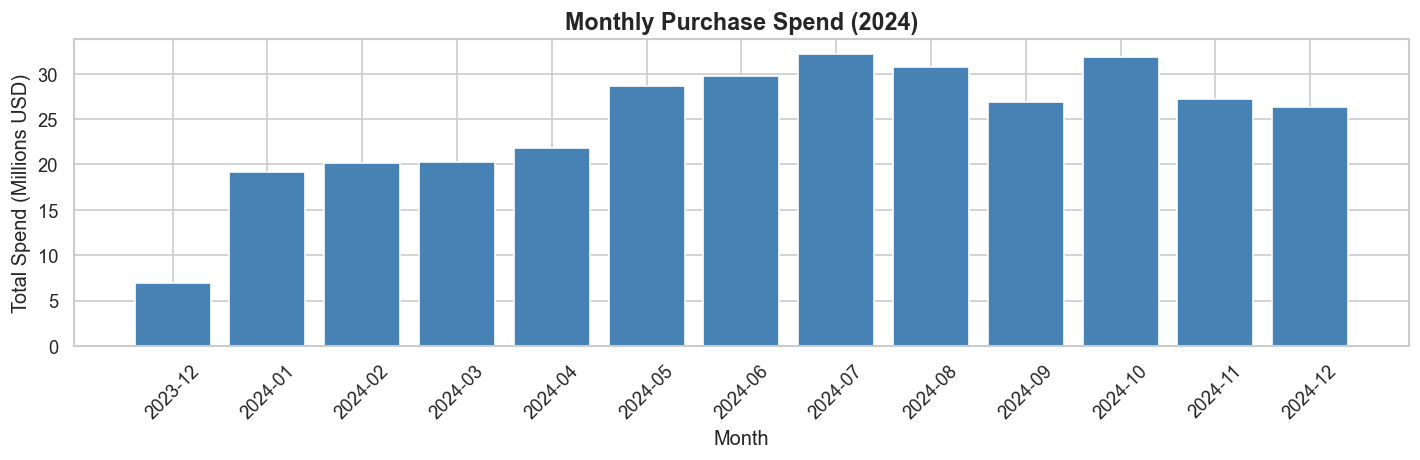

In [16]:
# ─────────────────────────────────────────────
# PURCHASES — MONTHLY TREND
# ─────────────────────────────────────────────

monthly_purchases = pd.read_sql_query("""
    SELECT
        STRFTIME('%Y-%m', PODate)       AS Month,
        COUNT(*)                        AS NumOrders,
        SUM(Quantity)                   AS TotalUnits,
        ROUND(SUM(Dollars), 2)          AS TotalDollars
    FROM purchases
    WHERE PurchasePrice > 0
      AND Dollars > 0
    GROUP BY STRFTIME('%Y-%m', PODate)
    ORDER BY Month
""", conn)

print(monthly_purchases.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly_purchases['Month'], 
       monthly_purchases['TotalDollars'] / 1_000_000,
       color='steelblue', edgecolor='white')
ax.set_title('Monthly Purchase Spend (2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Spend (Millions USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Key Findings — Purchases

- **2,372,474 transactions** across **126 vendors**, **10,664 brands** and **80 stores**
- **PO dates start Dec 2023 and Pay dates extend to Feb 2025** — normal in 
  procurement, orders placed in December get paid the following year
- **Total purchase spend: 321.9 million dollars** at an average of 135.68 dollars per line item
- **153 zero-price records exist** — same records flagged in `get_vendor_summary.py` 
  and already filtered out in our pipeline with `WHERE PurchasePrice > 0`
- **Clear seasonality in purchasing** — spend ramps up significantly from May 
  through August, peaking in July at 32.2 million dollars. This aligns with 
  summer demand for spirits and beverages
- **December purchases (2023) of 6.9M** are included — these are valid carry-over 
  orders that were received and invoiced in January 2024

### 2.6 Sales
This is the largest and most important table — 12.8 million daily transaction 
records across all stores, brands and vendors for 2024.
This table drives the revenue and profitability metrics in the vendor summary.

In [17]:
# ─────────────────────────────────────────────
# SALES — KEY STATS (via SQL to avoid loading 1.4GB)
# ─────────────────────────────────────────────

print("=== Sales — Key Stats ===\n")

stats = pd.read_sql_query("""
    SELECT
        COUNT(*)                            AS TotalRecords,
        COUNT(DISTINCT VendorNo)            AS UniqueVendors,
        COUNT(DISTINCT Brand)               AS UniqueBrands,
        COUNT(DISTINCT Store)               AS UniqueStores,
        MIN(SalesDate)                      AS EarliestSale,
        MAX(SalesDate)                      AS LatestSale,
        SUM(SalesQuantity)                  AS TotalUnitsSold,
        ROUND(SUM(SalesDollars), 2)         AS TotalSalesDollars,
        ROUND(AVG(SalesPrice), 2)           AS AvgSalesPrice,
        ROUND(SUM(ExciseTax), 2)            AS TotalExciseTax,
        SUM(CASE WHEN SalesDollars = 0
            THEN 1 ELSE 0 END)              AS ZeroDollarSales
    FROM sales
""", conn)

for col in stats.columns:
    print(f"  {col:<25} : {stats[col].iloc[0]}")

=== Sales — Key Stats ===

  TotalRecords              : 12825363
  UniqueVendors             : 127
  UniqueBrands              : 11237
  UniqueStores              : 80
  EarliestSale              : 2024-01-01 00:00:00
  LatestSale                : 2024-12-31 00:00:00
  TotalUnitsSold            : 32917876
  TotalSalesDollars         : 452062952.02
  AvgSalesPrice             : 15.69
  TotalExciseTax            : 18974240.74
  ZeroDollarSales           : 55


  Month  TotalUnitsSold  TotalSalesDollars  TotalExciseTax
2024-01         2194959        29854027.92      1233308.90
2024-02         2125272        28876607.23      1231865.53
2024-03         2219626        28988411.94      1238463.64
2024-04         2289425        30723734.63      1337965.19
2024-05         2624467        36041210.52      1536529.96
2024-06         2858944        39290701.46      1690625.08
2024-07         3439606        49696466.85      2164742.64
2024-08         2892258        39056166.03      1687284.83
2024-09         2840043        38477538.83      1571446.13
2024-10         2724657        36433141.73      1552970.30
2024-11         2950496        42312696.86      1746321.24
2024-12         3758000        52312248.02      1982625.61


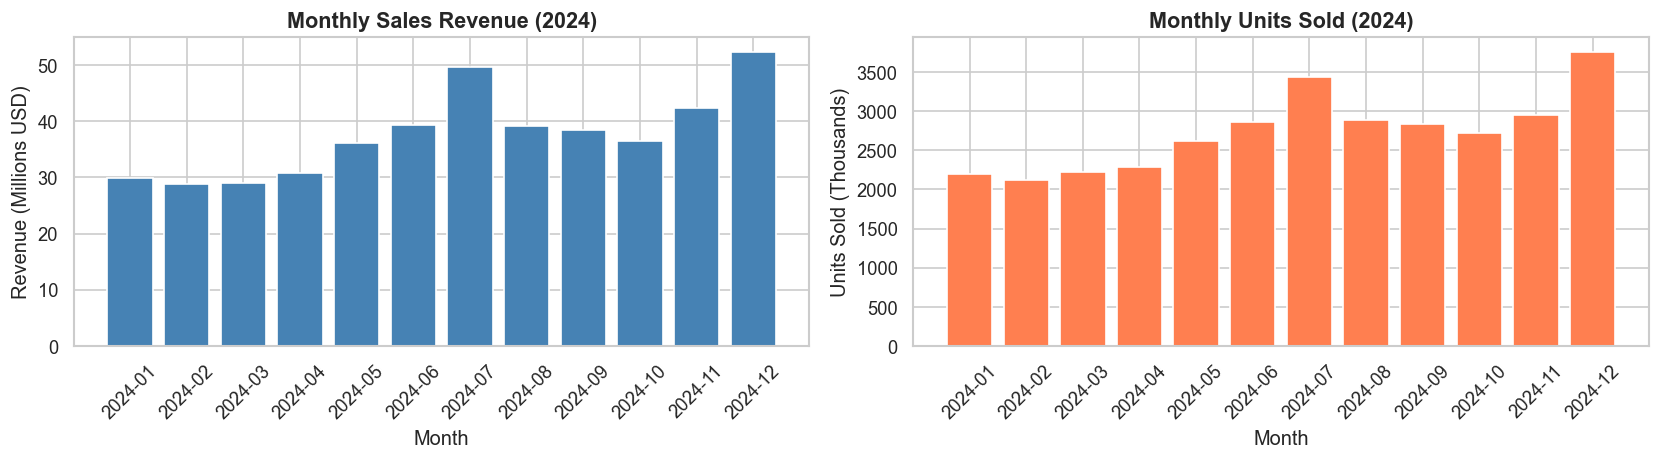

In [18]:
# ─────────────────────────────────────────────
# SALES — MONTHLY REVENUE TREND
# ─────────────────────────────────────────────

monthly_sales = pd.read_sql_query("""
    SELECT
        STRFTIME('%Y-%m', SalesDate)    AS Month,
        SUM(SalesQuantity)              AS TotalUnitsSold,
        ROUND(SUM(SalesDollars), 2)     AS TotalSalesDollars,
        ROUND(SUM(ExciseTax), 2)        AS TotalExciseTax
    FROM sales
    WHERE SalesDollars > 0
    GROUP BY STRFTIME('%Y-%m', SalesDate)
    ORDER BY Month
""", conn)

print(monthly_sales.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Revenue trend
axes[0].bar(monthly_sales['Month'],
            monthly_sales['TotalSalesDollars'] / 1_000_000,
            color='steelblue', edgecolor='white')
axes[0].set_title('Monthly Sales Revenue (2024)', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (Millions USD)')
axes[0].tick_params(axis='x', rotation=45)

# Units sold trend
axes[1].bar(monthly_sales['Month'],
            monthly_sales['TotalUnitsSold'] / 1_000,
            color='coral', edgecolor='white')
axes[1].set_title('Monthly Units Sold (2024)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Units Sold (Thousands)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [19]:
# ─────────────────────────────────────────────
# SALES vs PURCHASES — MONTHLY COMPARISON
# ─────────────────────────────────────────────

# Merge monthly sales and purchases for comparison
monthly_comparison = monthly_sales.merge(
    monthly_purchases[['Month', 'TotalDollars']].rename(
        columns={'TotalDollars': 'TotalPurchaseDollars'}
    ),
    on='Month', how='inner'
)

monthly_comparison['GrossMargin'] = (
    (monthly_comparison['TotalSalesDollars'] - 
     monthly_comparison['TotalPurchaseDollars']) /
     monthly_comparison['TotalSalesDollars'] * 100
).round(2)

print("=== Monthly Sales vs Purchases ===\n")
print(monthly_comparison[['Month', 'TotalSalesDollars', 
                           'TotalPurchaseDollars', 
                           'GrossMargin']].to_string(index=False))

=== Monthly Sales vs Purchases ===

  Month  TotalSalesDollars  TotalPurchaseDollars  GrossMargin
2024-01        29854027.92           19138815.42        35.89
2024-02        28876607.23           20147364.53        30.23
2024-03        28988411.94           20252968.80        30.13
2024-04        30723734.63           21798729.53        29.05
2024-05        36041210.52           28693060.33        20.39
2024-06        39290701.46           29699192.07        24.41
2024-07        49696466.85           32193842.50        35.22
2024-08        39056166.03           30747883.70        21.27
2024-09        38477538.83           26840919.81        30.24
2024-10        36433141.73           31836531.74        12.62
2024-11        42312696.86           27252267.02        35.59
2024-12        52312248.02           26349072.86        49.63


#### Key Findings — Sales

- **12.8 million transactions** — clean data, only 55 zero dollar sales (0.0004%)
- **Total revenue: 452 million dollars** against 321.9 million dollars in purchases 
  — overall gross margin of approximately 29.4% for the full year
- **Total excise tax: 18.97 million dollars** — significant cost to track separately
- **Strong seasonality detected:**
  - Summer peak — July is the strongest month at 49.7M revenue (+66% above January)
  - December is the second highest at 52.3M — holiday season demand
  - February and March are the weakest months
- **Sales always exceed purchases every month** — business is consistently profitable 
  at the aggregate level

#### Key Finding — Gross Margin Volatility

- **October has the lowest gross margin at 12.62%** — purchases were high 
  (31.8M) but sales were relatively low (36.4M), suggesting over-purchasing 
  ahead of Q4
- **December has the highest gross margin at 49.63%** — holiday sales revenue 
  spiked while purchases were controlled, maximising profitability
- **January gross margin is unusually high at 35.89%** — likely because December 
  purchases were already paid for and January is drawing down existing stock
- This volatility in monthly margins is an important finding for inventory 
  planning and purchasing strategy

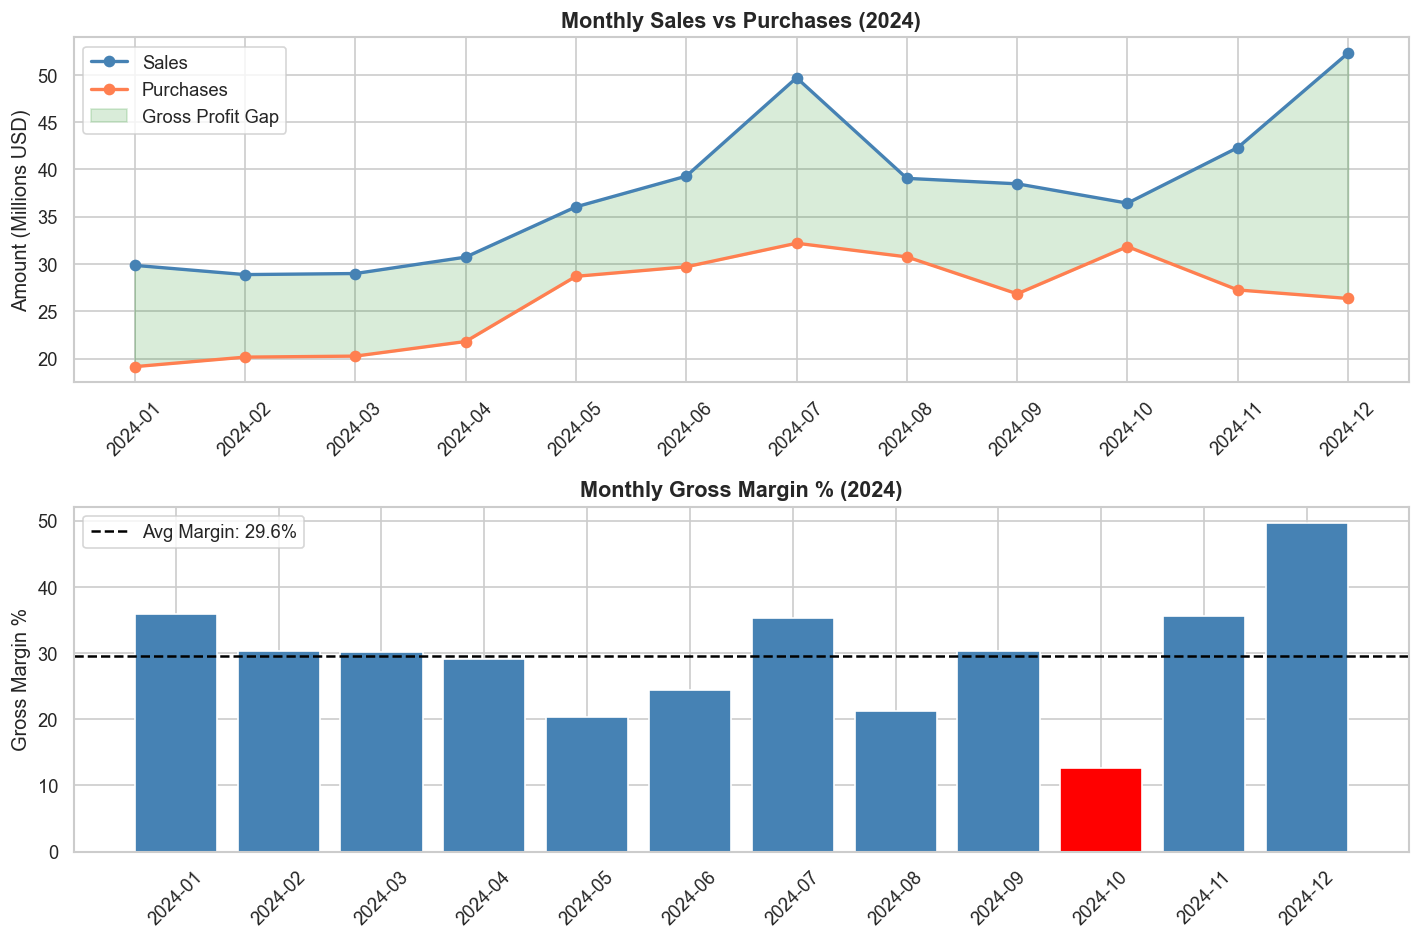

In [20]:
# ─────────────────────────────────────────────
# SALES — GROSS MARGIN TREND VISUALIZATION
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Sales vs Purchases
axes[0].plot(monthly_comparison['Month'],
             monthly_comparison['TotalSalesDollars'] / 1_000_000,
             marker='o', color='steelblue', linewidth=2, label='Sales')
axes[0].plot(monthly_comparison['Month'],
             monthly_comparison['TotalPurchaseDollars'] / 1_000_000,
             marker='o', color='coral', linewidth=2, label='Purchases')
axes[0].fill_between(monthly_comparison['Month'],
                     monthly_comparison['TotalSalesDollars'] / 1_000_000,
                     monthly_comparison['TotalPurchaseDollars'] / 1_000_000,
                     alpha=0.15, color='green', label='Gross Profit Gap')
axes[0].set_title('Monthly Sales vs Purchases (2024)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Amount (Millions USD)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Gross Margin trend
axes[1].bar(monthly_comparison['Month'],
            monthly_comparison['GrossMargin'],
            color=['red' if x < 20 else 'steelblue' 
                   for x in monthly_comparison['GrossMargin']],
            edgecolor='white')
axes[1].axhline(monthly_comparison['GrossMargin'].mean(),
                color='black', linestyle='--', linewidth=1.5,
                label=f"Avg Margin: {monthly_comparison['GrossMargin'].mean():.1f}%")
axes[1].set_title('Monthly Gross Margin % (2024)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Gross Margin %')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Vendor Sales Summary — Quality Check

Now we profile the `vendor_sales_summary` table that was built by 
`get_vendor_summary.py` to validate its quality before moving to 
the full vendor analysis notebook.

In [21]:
# ─────────────────────────────────────────────
# VENDOR SALES SUMMARY — PROFILE
# ─────────────────────────────────────────────

vss = pd.read_sql_query("SELECT * FROM vendor_sales_summary", conn)

print(f"Shape: {vss.shape}")
print(f"\nNull Counts:\n{vss.isnull().sum()[vss.isnull().sum() > 0]}")
print(f"\nKey Metrics Summary:")
print(vss[['TotalPurchaseDollars', 'TotalSalesDollars', 'GrossProfit',
           'ProfitMargin%', 'NetProfitMargin%', 
           'StockTurnover', 'AllocatedFreightCost']].describe().round(2))

Shape: (10514, 26)

Null Counts:
Series([], dtype: int64)

Key Metrics Summary:
       TotalPurchaseDollars  TotalSalesDollars  GrossProfit  ProfitMargin%  \
count              10514.00           10514.00     10514.00       10514.00   
mean               30589.56           42954.17     12364.62         -15.89   
std               124047.85          168977.76     46576.62         447.29   
min                    0.71               1.98    -52002.78      -23730.64   
25%                  479.36             809.82        66.98          15.35   
50%                 3836.42            5599.70      1496.49          30.78   
75%                21280.71           29524.25      8970.04          40.21   
max              3811251.60         5101919.51   1290667.91          99.72   

       NetProfitMargin%  StockTurnover  AllocatedFreightCost  
count          10514.00       10514.00              10514.00  
mean             -16.48           1.74                155.89  
std              449.57     

In [22]:
# ─────────────────────────────────────────────
# NEGATIVE GROSS PROFIT INVESTIGATION
# This finding directly informed the decision to add
# the IsUnderperforming flag in get_vendor_summary.py
# ─────────────────────────────────────────────

negative = vss[vss['GrossProfit'] < 0]

print(f"Negative Gross Profit Records : {len(negative)}")
print(f"As % of Total Records         : {len(negative)/len(vss)*100:.1f}%")
print(f"Total Negative Profit Value   : ${negative['GrossProfit'].sum():,.2f}")

print(f"\nVendors with most negative profit records:")
print(negative['VendorName'].value_counts().head(10).to_string())

print(f"\nWorst 5 performing products:")
print(negative.nsmallest(5, 'GrossProfit')[
    ['VendorName', 'Description', 'TotalPurchaseDollars',
     'TotalSalesDollars', 'GrossProfit']
].to_string(index=False))

print(f"\nDistribution of negative profits:")
print(negative['GrossProfit'].describe().round(2))

Negative Gross Profit Records : 1949
As % of Total Records         : 18.5%
Total Negative Profit Value   : $-4,068,030.17

Vendors with most negative profit records:
VendorName
MARTIGNETTI COMPANIES         279
PERFECTA WINES                194
ULTRA BEVERAGE COMPANY LLP    193
M S WALKER INC                166
PINE STATE TRADING CO         115
CONSTELLATION BRANDS INC       72
SOUTHERN WINE & SPIRITS NE     65
E & J GALLO WINERY             63
KOBRAND CORPORATION            54
VINILANDIA USA                 52

Worst 5 performing products:
             VendorName               Description  TotalPurchaseDollars  TotalSalesDollars  GrossProfit
JIM BEAM BRANDS COMPANY   Kilbeggan Irish Whiskey              72275.32           20272.54    -52002.78
 REMY COINTREAU USA INC Remy Martin XO Excellence              59398.95           21237.26    -38161.69
         PERFECTA WINES  Whistle Pig Boss Hog Rye              44489.34           11062.63    -33426.71
         M S WALKER INC             I

#### Decision — Negative Gross Profit Records

**Finding:** 18.5% of vendor-brand records show negative gross profit 
totalling -4,068,030 dollars.

**Investigation:**
- The median loss is only -475 dollars — most negative records are small
- However some extreme cases exist (min = -52,002 dollars)
- MARTIGNETTI COMPANIES leads with 279 negative records despite being 
  the second highest revenue vendor overall
- This pattern is consistent with large distributors carrying hundreds 
  of SKUs where some inevitably underperform

**Decision:** Retain all negative records but add an `IsUnderperforming` 
flag (True/False) to the vendor summary table. This allows Power BI 
users to toggle between full view and profitable-only view without 
permanently losing data.

**Action:** `IsUnderperforming = GrossProfit < 0` will be added to 
`get_vendor_summary.py` in the `add_features()` function.

#### Additional Finding — Profit Margin Outliers

- **Mean ProfitMargin% of -15.89 is misleading** — it is being dragged down 
  by extreme outliers where sales dollars are very small against large purchases
- **Median of 30.78% is the true central tendency** — this is a healthy margin 
  for a liquor distributor
- **Worst performing product: Kilbeggan Irish Whiskey (JIM BEAM)** — 
  purchased 72,275 dollars worth but only sold 20,272 dollars — 
  a classic overstock/poor demand planning situation
- **Russian Standard Vodka lost 29,280 dollars** — likely impacted by 
  geopolitical factors affecting consumer sentiment in 2024
- For Power BI reporting, **median margin should be used instead of mean** 
  to avoid misleading stakeholders

## 4. EDA Summary & Decisions

A consolidated record of all findings and decisions made during 
this exploratory analysis.

### Data Quality Issues Found & Resolved

| Table | Issue | Resolution |
|---|---|---|
| vendor_invoice | Approval column 93% null | Dropped in ingestion_db.py |
| end_inventory | 1,284 null City values (Store 46) | Filled using begin_inventory store-city map |
| purchase_prices | 2 zero retail price, 1 zero purchase price | Filtered in get_vendor_summary.py |
| purchases | 153 zero price records | Filtered with WHERE PurchasePrice > 0 |
| sales | 55 zero dollar sales | Filtered with WHERE SalesDollars > 0 |
| vendor_sales_summary | ProfitMargin% mean skewed by outliers | Use median for reporting, not mean |
| vendor_sales_summary | 1,949 negative gross profit records | Flag with IsUnderperforming column |

### Key Business Insights Found

| Finding | Detail |
|---|---|
| Business expanded in 2024 | 1 new store, 1,559 new brands added |
| Inventory value grew 17.1% | From 68M to 79.7M — purchasing outpaced sales |
| Peak sales month: December | 52.3M revenue driven by holiday demand |
| Peak purchase month: July | 32.2M — summer stocking ahead of demand |
| October margin warning | Lowest gross margin at 12.62% — over-purchasing |
| Overall gross margin: ~29.4% | Healthy for liquor distribution industry |
| Top loss-making product | Kilbeggan Irish Whiskey (-52,002 dollars) |

### Actions for Pipeline (get_vendor_summary.py)

1. Add `IsUnderperforming = GrossProfit < 0` flag to `add_features()` function
2. Add comment referencing this notebook as justification

In [23]:
# ─────────────────────────────────────────────
# CLOSE DATABASE CONNECTION
# ─────────────────────────────────────────────

conn.close()
print("EDA Complete — database connection closed.")
print("Next step: Update get_vendor_summary.py then build 02_Vendor_Analysis.ipynb")

EDA Complete — database connection closed.
Next step: Update get_vendor_summary.py then build 02_Vendor_Analysis.ipynb
